In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Custom settings
plt.style.use('classic')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['savefig.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['figure.dpi'] = 100

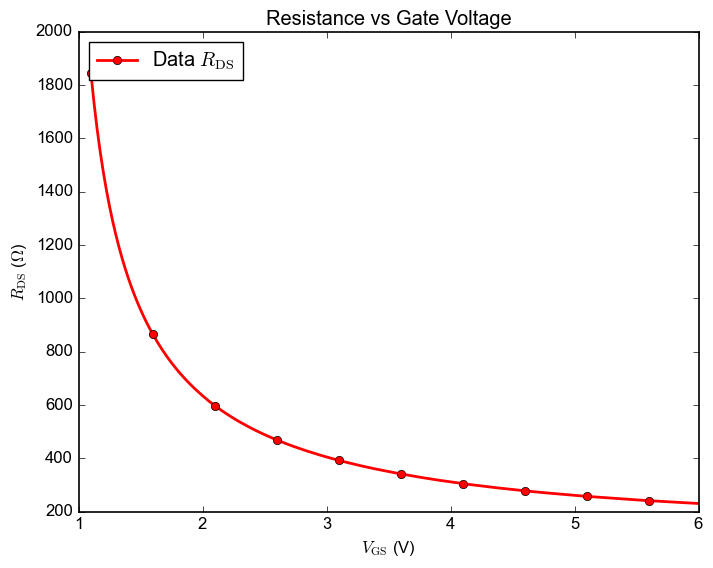

In [2]:
data = np.loadtxt("./Mobility/20262004004.dat")
V_GS = data[:, 0]
I_DS = data[:, 2]
V_DS = data[:, 3]
V_12 = data[:, 6]
sigma = data[:, 7]
R_DS = V_DS / I_DS

plt.plot(V_GS, R_DS, lw=2, label=r'Data $R_\text{DS}$', color='red', marker='o', linestyle='-', markevery=40)
plt.xlabel(r"$V_\text{GS}$ (V)")
plt.ylabel(r"$R_\text{DS}$ ($\Omega$)")
plt.legend(frameon=True, loc='upper left', numpoints=1)
plt.title("Resistance vs Gate Voltage")
plt.show()


a = Rc = 68.2245 ± 1.28
b = 811.468 ± 2.08
R^2 = 0.997449


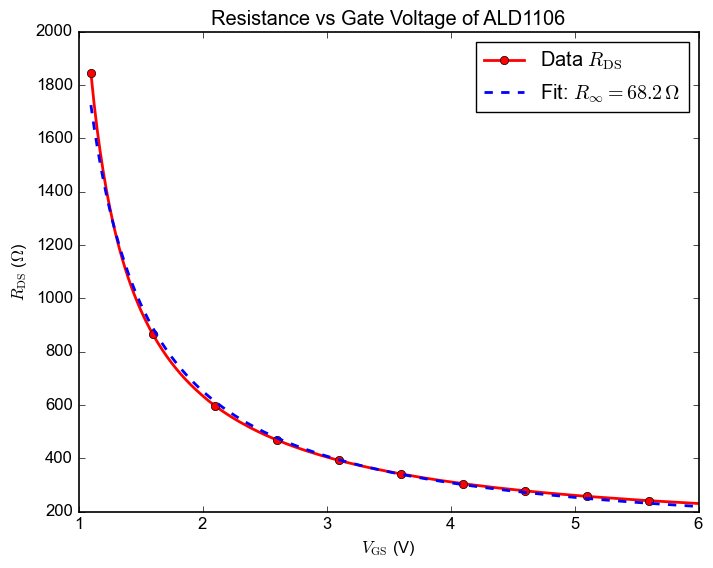

In [3]:
V_T = 0.61
def func(x, a, b):
    return a + b/ (x - V_T)

popt, pcov = curve_fit(func, V_GS, R_DS)
R_fit = func(V_GS, *popt)
a, b = popt

# Coefficient of determination
ss_res = np.sum((R_DS - R_fit) ** 2)
ss_tot = np.sum((R_DS - np.mean(R_DS)) ** 2)
r2 = 1 - (ss_res / ss_tot)

# 1-sigma parameter uncertainties from covariance matrix
perr = np.sqrt(np.diag(pcov))
a_err, b_err = perr


print(f"a = Rc = {a:.6g} ± {a_err:.3g}")
print(f"b = {b:.6g} ± {b_err:.3g}")
print(f"R^2 = {r2:.6f}")


plt.plot(V_GS, R_DS, lw=2, label=r'Data $R_\text{DS}$', color='red', marker='o', linestyle='-', markevery=40)
plt.plot(V_GS, R_fit, lw=2, label=rf'Fit: $R_\infty = {a:.3g}\,\Omega$', color='blue', linestyle='--')
plt.xlabel(r"$V_\text{GS}$ (V)")
plt.ylabel(r"$R_\text{DS}$ ($\Omega$)")
plt.legend(frameon=True, loc='upper right', numpoints=1)
plt.title("Resistance vs Gate Voltage of ALD1106")
plt.savefig("resistance_fit.eps", format='eps', bbox_inches='tight')
plt.show()